In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp


from myutils_2233 import set_detectors, load_tables, cov_resp
from myutils_2233 import ln_likelihood_full_jit, ln_likelihood_full
from other_utils import calculate_SNR

from scipy.linalg import toeplitz

import lal
from gwpy.timeseries import TimeSeries

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/simulations_220_330/../../src/myutils_2233.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Likelihood extras
factor     = 10

seed       = 31567 
T          = 0.2
srate      = 4096 
t0         = 0.0
fmin       = 8
fmax       = 1500

# Fixed sky location (set to injection parameters)
ra         = 3.5
dec        = 0.73

tgps       = 1420888141.2379541 

psdH_path  = "../../data/PSDs/PSD_H1_GW250114.txt"
psdL_path  = "../../data/PSDs/PSD_L1_GW250114.txt"
qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"

In [4]:
# Prior limits
limits = [
    [30.0, 450.0],
    [0., 0.99],
    [0., 8.0],
    [0., 6.283185307179586],
    [0., 8.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]
    ]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

Load PSDs, and interpolate 22, 33 mode frequency as a function of mass and spin (from Berti fits). Also initiate detector location for likelihood

In [5]:
psdH, psdL, omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(psdH_path, psdL_path, qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

L_H, L_L, resp_H, resp_L = cov_resp(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
set_detectors(resp_H, resp_L)

Load data strain. 'old' corresponds to data for FULL-SKY analysis

In [6]:
h_H_t = onp.loadtxt('./H1-sim-old.txt')
h_L_t = onp.loadtxt('./L1-sim-old.txt')

Testing likelihood with injection parameters.

In [7]:
M_obs      = 300 
chi_obs    = 0.8 
A220_obs   = 0.7
P220_obs   = 4.1 
A330_obs   = 0.17 
P330_obs   = 1.5 
ra         = 3.5
dec        = 0.73
psi        = 1.329
iota       = 1.3 

theta_GT = jnp.array([M_obs, chi_obs, A220_obs, P220_obs, A330_obs, P330_obs, onp.cos(iota), ra, onp.sin(dec), psi])
print("Test: logL evaluated at GT (TD): ", ln_likelihood_full(
            dataH=h_H_t, dataL=h_L_t, params=theta_GT, gmst=gmst, L_H=L_H, L_L=L_L, 
            omega_22_r=omega_22_r, omega_22_i=omega_22_i, omega_33_r=omega_33_r, omega_33_i=omega_33_i, 
            T=T, srate=srate, t0=t0
            )
    )

Test: logL evaluated at GT (TD):  -2.8306835219012425e-29


Calculate SNR

In [8]:
snr_H = calculate_SNR(h_H_t, L_H)
snr_L = calculate_SNR(h_L_t, L_L)
print('total SNR : ', onp.sqrt(snr_H**2 + snr_L**2))

total SNR :  24.3851740492589


Set up the numpyro model. Computes likelihood as a function of $\theta$

In [9]:
low  = jnp.asarray(low,  dtype=jnp.float64)  
high = jnp.asarray(high, dtype=jnp.float64)  

# Sky location set to injection. 
theta_fixed_sky = jnp.array([ra, onp.sin(dec)]) 

def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_22_r=omega_22_r, omega_22_i=omega_22_i,
            omega_33_r=omega_33_r, omega_33_i=omega_33_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_22_r=omega_22_r, omega_22_i=omega_22_i,
    omega_33_r=omega_33_r, omega_33_i=omega_33_i,
    T=T, srate=srate, t0=t0
)

def model_fixed_sky():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    theta = jnp.concatenate([theta_free[:-1], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
    numpyro.factor("loglike", loglik_fn(theta))

In [10]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_fixed_sky = NestedSampler(
    model_fixed_sky,
    constructor_kwargs=dict(
        num_live_points=10000,   
        max_samples=500_000,   
        verbose=False,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_fixed_sky.run(rng_run)
ns_fixed_sky.print_summary()
posterior_fixed_sky = ns_fixed_sky.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 41372139
samples: 245196
phantom samples: 0
likelihood evals / sample: 168.7
phantom fraction (%): 0.0%
--------
logZ=-21.645 +- 0.051
max(logL)=-0.012
H=-17.86
ESS=25248
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 292.0 +- 17.0 | 271.0 / 292.0 / 313.0 | 301.0 | 301.0
theta[1]: 0.766 +- 0.075 | 0.693 / 0.776 / 0.834 | 0.803 | 0.803
theta[2]: 0.78 +- 0.25 | 0.52 / 0.76 / 1.02 | 0.71 | 0.71
theta[3]: 2.7 +- 1.7 | 0.7 / 2.7 / 4.6 | 1.0 | 1.0
theta[4]: 0.19 +- 0.21 | 0.05 / 0.13 / 0.4 | 0.18 | 0.18
theta[5]: 3.2 +- 1.8 | 0.8 / 3.2 / 5.7 | 4.7 | 4.7
theta[6]: 0.26 +- 0.31 | -0.09 / 0.23 / 0.7 | 0.25 | 0.25
theta[7]: 1.81 +- 0.92 | 0.5 / 1.66 / 2.98 | 2.88 | 2.88
--------


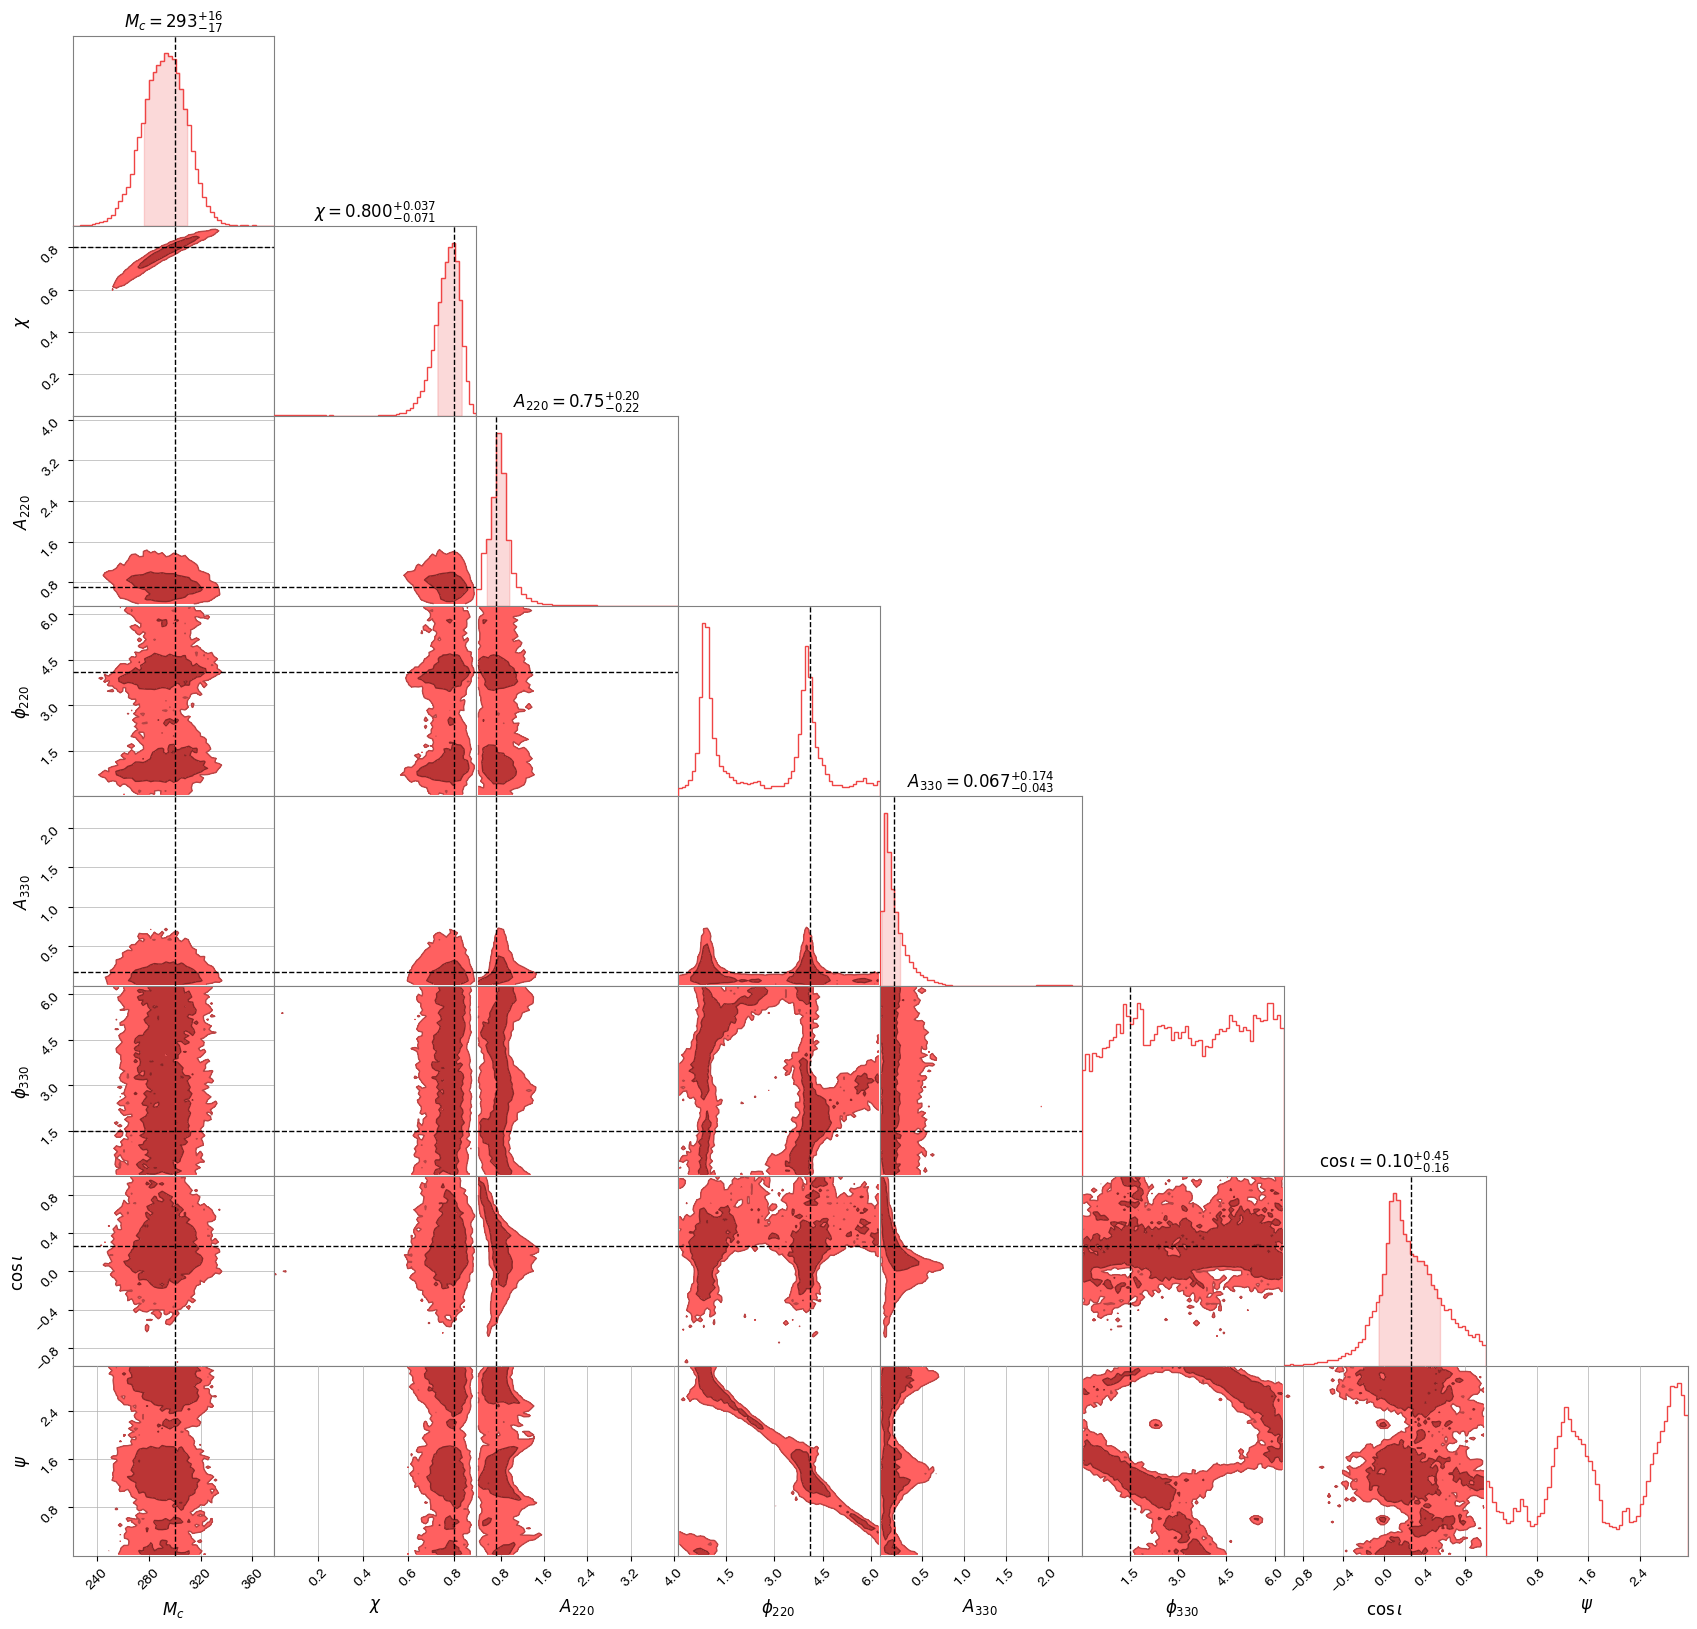

In [11]:
ns_fixed_tail_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{330}$', r'$\phi_{330}$', r'$\cos\iota$', r'$\psi$']

truths = {}
for i in range(len(ns_fixed_tail_parameters)):
    truths[ns_fixed_tail_parameters[i]] = theta_GT[i]

df_ns_fixed_ext = pd.DataFrame(posterior_fixed_sky['theta'], columns=ns_fixed_tail_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns_fixed_ext, color='r', name="Fixed sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], bins=60, plot_cloud=0, smooth=0, bar_shade=1))
c.set_plot_config(
    PlotConfig(
        # flip=True,
        # labels=ns_parameters,
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
c.add_truth(Truth(location=truths, color='#000000'))
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

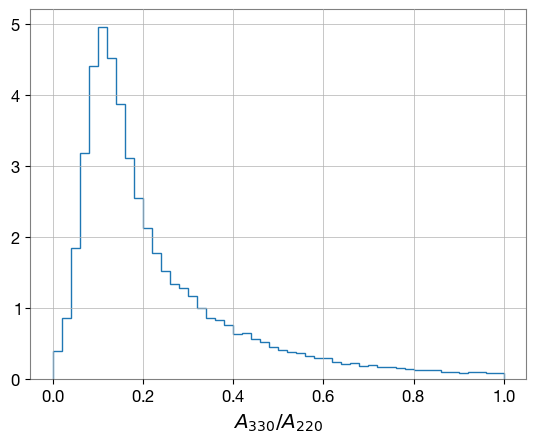

In [12]:
plt.hist(posterior_fixed_sky['theta'][:,4]/posterior_fixed_sky['theta'][:,2], bins=50, histtype='step', density=1)
plt.xlabel(r'$A_{330}/A_{220}$')
plt.show()

Saving the samples (set the posterior_dir)

In [13]:
posterior_dir = '../posterior_files/simulations_220_330/'
onp.save(posterior_dir + 'posterior.noiseless-sim.fixed-sky.npy', onp.asarray(posterior_fixed_sky['theta']))

In [14]:
theta_GT

Array([3.00000000e+02, 8.00000000e-01, 7.00000000e-01,
       4.10000000e+00, 1.70000000e-01, 1.50000000e+00,
       2.67498829e-01, 3.50000000e+00, 6.66869635e-01,
       1.32900000e+00], dtype=float64)